# Single travel speed acquisition

This notebook takes a before overview, runs one scan window through the middle of the image at a fixed pixel-per-frame travel speed, then takes an after overview.

The scan window always moves down in image coordinates. The overview and scan images use the same image shape so the projected path can be plotted directly.

### Quick Start Code Cell

In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

## 0. Ping Tango servers

In [2]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ["stage", "scan", "eds", "camera", "data", "microscope"]

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())

asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/microscope/default ON


## 1. Connect to devices

In [3]:
SCAN_DEVICE = "asyncroscopy/scan/default"
MICROSCOPE_DEVICE = "asyncroscopy/microscope/default"
DATA_DEVICE = "asyncroscopy/data/default"

In [4]:
scan = tango.DeviceProxy(SCAN_DEVICE)
microscope = tango.DeviceProxy(MICROSCOPE_DEVICE)
data = tango.DeviceProxy(DATA_DEVICE)

for proxy in (scan, microscope, data):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())

scan      : ON
microscope: ON
data      : ON


In [5]:
TILED_HOST = "10.46.217.241"
TILED_PORT = 9091
save_path = "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/"

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path


if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

Tiled server is not responding; starting it from the DATA device...
{
  "host": "10.46.217.241",
  "port": 9091,
  "uri": "http://10.46.217.241:9091",
  "save_path": "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/",
  "tiled_server": "yes",
  "tiled_server_status": "running; watcher started"
}


In [8]:
client = from_uri(f"http://{TILED_HOST}:{TILED_PORT}")
list(client)

[]

## 2. Set scan params

In [9]:
scan.Activate(["haadf"])
scan.haadf = True
scan.bf = False

scan.imsize = 512

## 3. Before overview

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

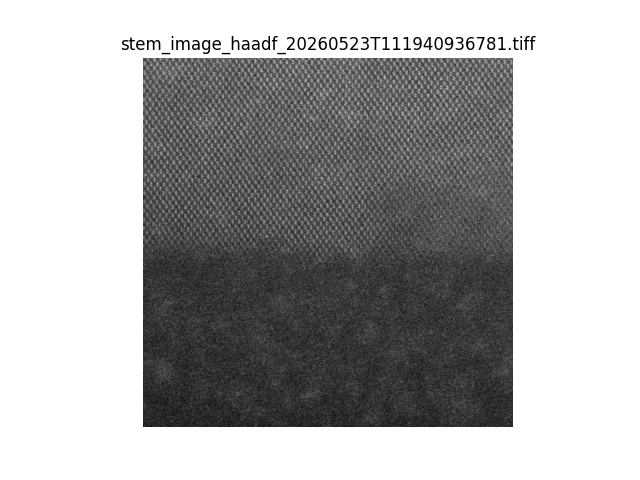

In [27]:
scan.dwell_time = 10e-6
scan.scan_region = [0, 0, 1, 1]

before_key = microscope.get_scanned_image_advanced()

# keep trying to read the overview image until it is available
before_overview = None
while before_overview is None:
    try:
        before_overview = client[before_key].read()
    except Exception as e:
        print(f"Overview image not available yet: {e}")
        time.sleep(1)

plt.figure()
plt.imshow(before_overview, cmap="gray")
plt.title(before_key)
plt.axis("off")

## Exp Params

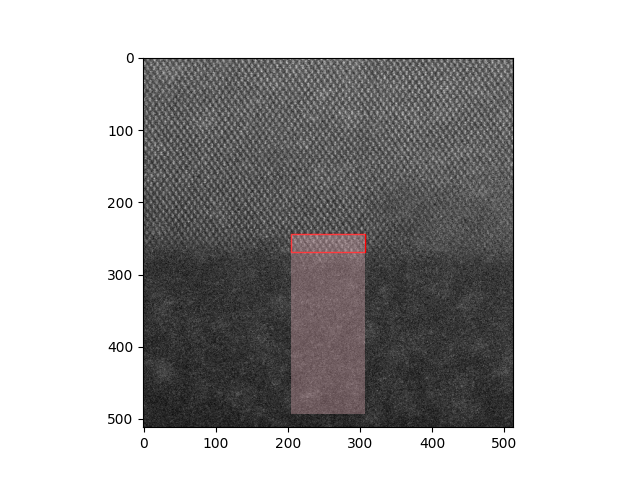

In [29]:
# inputs ---------
travel_per_frame = 2 # in pixel
total_travel = 250 # in pixel

region_width = 0.2
region_height = 0.05

scan.dwell_time = 500e-6
# ----------------


left = 0.5 - region_width / 2
start_top = 0.5 - region_height / 2

step_size = travel_per_frame / before_overview.shape[0]
n_steps = int(total_travel / travel_per_frame)

# plot the projected path
plt.figure()
plt.imshow(before_overview, cmap="gray")

# starting rectangle
rect = plt.Rectangle((left*scan.imsize, start_top*scan.imsize), region_width*scan.imsize, region_height*scan.imsize, edgecolor="red", facecolor="none")
plt.gca().add_patch(rect)

# path rectangle
rect = plt.Rectangle((left*scan.imsize, start_top*scan.imsize), region_width*scan.imsize, total_travel, facecolor="pink", alpha=0.3)
plt.gca().add_patch(rect)

plt.show()

## 4. Run one downward scan path

In [30]:
results = []
start_time = time.time()
for frame in range(n_steps):
    top = start_top + frame * step_size

    scan.scan_region = [left, top, region_width, region_height]
    key = microscope.get_scanned_image_advanced()

    elapsed_s = time.time() - start_time

    results.append({"frame": frame,
                    "time_s": elapsed_s,
                    "key": key,
                    "left": left,
                    "top": top,
                    "width": region_width,
                    "height": region_height})

    print(frame, key, "top", top)


0 stem_image_haadf_20260523T112001848744.tiff top 0.475
1 stem_image_haadf_20260523T112004664920.tiff top 0.47890625
2 stem_image_haadf_20260523T112008563079.tiff top 0.4828125
3 stem_image_haadf_20260523T112011165883.tiff top 0.48671875
4 stem_image_haadf_20260523T112013997884.tiff top 0.490625
5 stem_image_haadf_20260523T112016643994.tiff top 0.49453125
6 stem_image_haadf_20260523T112019587474.tiff top 0.4984375
7 stem_image_haadf_20260523T112022282519.tiff top 0.50234375
8 stem_image_haadf_20260523T112025565138.tiff top 0.50625
9 D:\microscopedata\tiled\ahoust17\2026_05_22_AtomFab\stem_image_haadf_20260523T112029156558.tiff top 0.51015625
10 stem_image_haadf_20260523T112033970831.tiff top 0.5140625
11 stem_image_haadf_20260523T112038052575.tiff top 0.51796875
12 stem_image_haadf_20260523T112040601205.tiff top 0.521875
13 stem_image_haadf_20260523T112042975645.tiff top 0.52578125
14 stem_image_haadf_20260523T112045252454.tiff top 0.5296875
15 stem_image_haadf_20260523T112047673170.ti

DevFailed: DevFailed[
    DevError[
        desc = ValueError: scan_region must fit within the relative [0, 1] scan area
        origin = Traceback (most recent call last):
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\server.py", line 177, in write_attr
                return get_worker().execute(write_method, self, value)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\green.py", line 110, in execute
                return fn(*args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\asyncroscopy\hardware\SCAN.py", line 111, in write_scan_region
                self._scan_region = self._validate_scan_region(value)
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\a

## 5. After overview

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

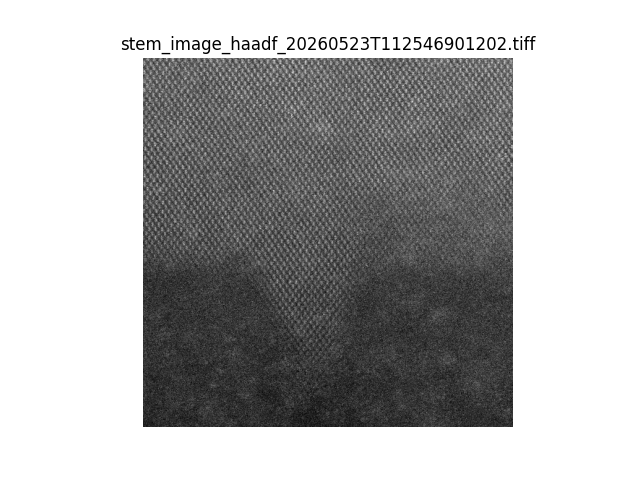

In [31]:
scan.dwell_time = 10e-6
scan.scan_region = [0, 0, 1, 1]

after_key = microscope.get_scanned_image_advanced()

# keep trying to read the overview image until it is available
after_overview = None
while after_overview is None:
    try:
        after_overview = client[after_key].read()
    except Exception as e:
        print(f"Overview image not available yet: {e}")
        time.sleep(1)

plt.figure()
plt.imshow(after_overview, cmap="gray")
plt.title(after_key)
plt.axis("off")

/var/folders/1h/36qxtl8567zdjv8nzdn4fzrr0000gn/T/ipykernel_39300/576338229.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,3, figsize=(15,5))


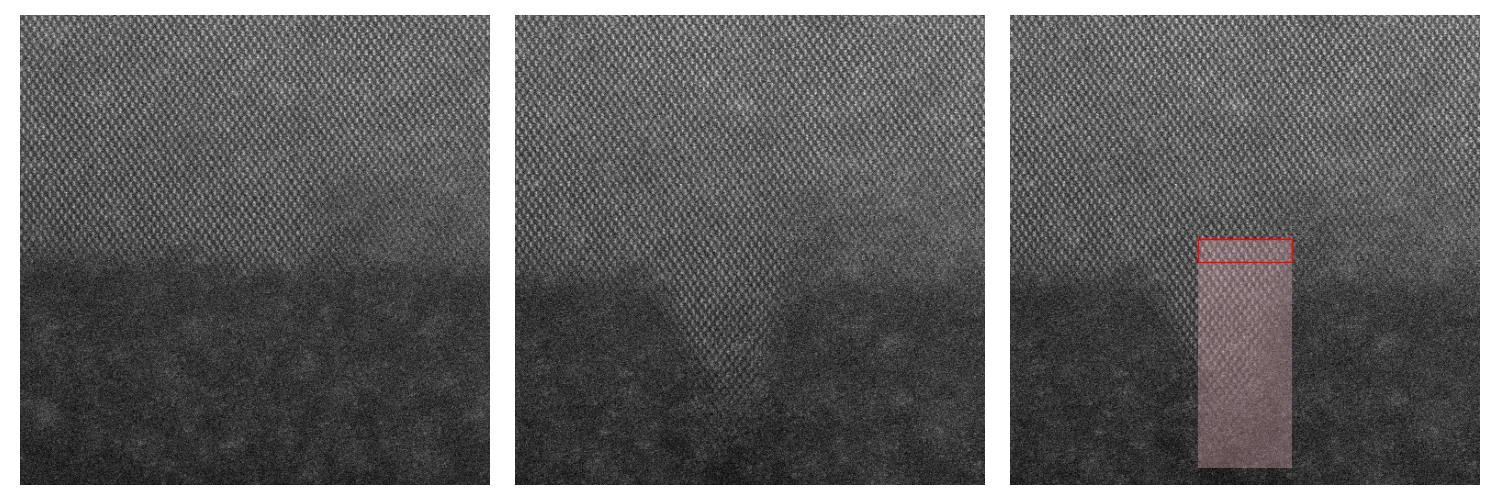

In [33]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(before_overview, cmap="gray")
ax[1].imshow(after_overview, cmap="gray")
ax[2].imshow(after_overview, cmap="gray")

rect = plt.Rectangle((left*scan.imsize, start_top*scan.imsize), region_width*scan.imsize, total_travel, facecolor="pink", alpha=0.3)
ax[2].add_patch(rect)
rect = plt.Rectangle((left*scan.imsize, start_top*scan.imsize), region_width*scan.imsize, region_height*scan.imsize, edgecolor="red", facecolor="none")
ax[2].add_patch(rect)

for a in ax:
    a.axis("off")
fig.tight_layout()